# Data Preprocessing
---

In [1]:
!pip -q install pandas numpy matplotlib seaborn statsmodels scipy beautifulsoup4 tqdm plotly PyPDF2 pdfplumber nbformat

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from dataclasses import dataclass
import argparse
from pathlib import Path
import re
import glob
from bs4 import BeautifulSoup
from tqdm import tqdm
from PyPDF2 import PdfReader
import pdfplumber
import warnings
import plotly.express as px


In [2]:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


warnings.simplefilter("ignore", category=FutureWarning)

from component.data_transformer_html import generate_csvs_from_folder
from component.csv_combiner import combine_csvs_from_folder
from component.pdf_processor import process_all_pdfs
from component.popularity import (
    prepare_popularity_data,
    clean_numeric,
    food_popularity,
    net_consumption,
    leftover_rate
)
from component.optimization import (
    prepare_optimization_data,
    run_meal_optimization,
    run_meal_optimization_ilp,
    generate_item_breakdown,
    run_size_based_optimization,
    run_proportional_monthly_optimization,
    analyze_annual_budget,
    calculate_actual_annual_cost,
    prepare_savings_analysis_df,
    analyze_savings_by_school_size
)

### Data Transformer (HTML)

In [ ]:
folder_path = "../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records"
output_dir = "../data/preprocessed-data/Lunch production"
generate_csvs_from_folder(folder_path, output_dir)

folder_path = "../data/FairfaxCounty/May 2025 Breakfast production records/May 2025 Breakfast production records"
output_dir = "../data/preprocessed-data/Breakfast production"
generate_csvs_from_folder(folder_path, output_dir)


### CSV Combiner (HTML)

In [ ]:
# Breakfast
input_dir = '../data/preprocessed-data/Breakfast production'
output_file = '../data/preprocessed-data/breakfast_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)


In [ ]:
# Lunch
input_dir = '../data/preprocessed-data/Lunch production'
output_file = '../data/preprocessed-data/lunch_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)

### PDF Processing

In [ ]:
# Define the input and output paths relative to the notebook's location
pdf_folder = "../data/FairfaxCounty/Item Sales Reports - Mar May 2025/Item Sales Reports - Mar May 2025"
output_file = "../data/preprocessed-data/sales.csv"

# Call the function to process all PDFs and generate the combined sales.csv
process_all_pdfs(pdf_folder, output_file)

---
# Data Cleaning and EDA
---

In [3]:
# Set plot style
sns.set(style="whitegrid")

### EDA of Breakfast Data: breakfast_combined

In [ ]:
# Load your dataset
dfb = pd.read_csv('../data/preprocessed-data/breakfast_combined.csv', low_memory=False)
dfb['School_Name'] = dfb['School_Name'].str.lower()
dfb.head()

,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Non-Reimbursable,Served_Total,Discarded_Total,Discarded_Cost,Subtotal_Cost,Left_Over_Total,Left_Over_Percent_of_Offered,Left_Over_Cost,Production_Cost_Total
0,aldrin elementary,5/01/2025,10041,Mini Maple Pancakes (Package),57,0,57,59,56,0,56,$21.84,0,0.00%,$0.00,$21.84,3,5.08%,$1.17,$23.01
1,aldrin elementary,5/01/2025,20001,1% White Milk (Each),33,0,33,37,34,0,34,$12.24,0,0.00%,$0.00,$12.24,3,8.11%,$1.08,$13.32
2,aldrin elementary,5/01/2025,20017,Orange (6 Slices per 1/2 cup),51,0,51,55,53,0,53,$18.02,0,0.00%,$0.00,$18.02,2,3.64%,$0.68,$18.70
3,aldrin elementary,5/01/2025,20038,Fat Free White Milk (Each),11,0,11,15,13,0,13,$4.29,0,0.00%,$0.00,$4.29,2,13.33%,$0.66,$4.95
4,aldrin elementary,5/01/2025,30003,Honey Cheerios Cereal (Each),10,0,10,10,7,0,7,$4.13,0,0.00%,$0.00,$4.13,3,30.00%,$1.77,$5.90


In [23]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (55646, 20)

Data types:
 School_Name                     object
Date                            object
Identifier                      object
Name                            object
Planned_Reimbursable             int64
Planned_Non-Reimbursable         int64
Planned_Total                    int64
Offered_Reimbursable             int64
Offered_Non-Reimbursable         int64
Offered_Total                    int64
Served_Reimbursable              int64
Served_Non-Reimbursable         object
Served_Total                     int64
Discarded_Total                 object
Discarded_Cost                  object
Subtotal_Cost                   object
Left_Over_Total                  int64
Left_Over_Percent_of_Offered    object
Left_Over_Cost                  object
Production_Cost_Total           object
dtype: object


In [24]:
# show statistics
dfb.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total
count,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000
mean,33.435431,0.081300,33.516731,45.235812,35.404432,0.507817,35.912249,0.129282,9.195450
std,63.312415,1.042007,63.355922,68.060557,58.877480,3.289844,59.028820,1.021627,21.275619
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,10.000000,5.000000,0.000000,6.000000,0.000000,0.000000
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,0.000000,3.000000
75%,40.000000,0.000000,40.000000,51.000000,40.000000,0.000000,41.000000,0.000000,10.000000
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,53.000000,985.000000


In [25]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 School_Name                     0
Date                            0
Identifier                      0
Name                            0
Planned_Reimbursable            0
Planned_Non-Reimbursable        0
Planned_Total                   0
Offered_Reimbursable            0
Offered_Non-Reimbursable        0
Offered_Total                   0
Served_Reimbursable             0
Served_Non-Reimbursable         0
Served_Total                    0
Discarded_Total                 0
Discarded_Cost                  0
Subtotal_Cost                   0
Left_Over_Total                 0
Left_Over_Percent_of_Offered    0
Left_Over_Cost                  0
Production_Cost_Total           0
dtype: int64


In [26]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [27]:
# overview look at food names
food_cat = dfb.groupby('Name')['Planned_Total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

Name
Apple Juice (Each)                                     453973
Orange Tangerine Juice (Each)                          248470
1% White Milk (Each)                                   211190
Mini Maple Pancakes (Package)                          140160
Red Delicious Apple (Each - serving)                    89769
Honey Cheerios Cereal (Each)                            76478
Cinnamon Toast Crunch Cereal, 25% Less Sugar (Each)     71307
Cinnamon Chex Cereal (Each)                             67403
Fat Free White Milk (Each)                              64173
Blueberry Chex Cereal (Each)                            59862
Name: Planned_Total, dtype: int64


### EDA of Lunch Data: lunch_combined

In [ ]:
# Load your dataset
dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv', low_memory=False)
dfl['School_Name'] = dfl['School_Name'].str.lower()
dfl.head()

/var/folders/th/m_nrt0q54qlbtf0hq75q_wt40000gn/T/ipykernel_8510/3363551025.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Non-Reimbursable,Served_Total,Discarded_Total,Discarded_Cost,Subtotal_Cost,Left_Over_Total,Left_Over_Percent_of_Offered,Left_Over_Cost,Production_Cost_Total
0,aldrin elementary,5/01/2025,10044,Soft Pretzel (1 pretzel),15,0,15,31,27,0,27,$5.94,0,0.00%,$0.00,$5.94,4,12.90%,$0.88,$6.82
1,aldrin elementary,5/01/2025,10062,Corn (1/4 cup (thawed)),92,0,92,155,152,0,152,$16.72,0,0.00%,$0.00,$16.72,3,1.94%,$0.33,$17.05
2,aldrin elementary,5/01/2025,20001,1% White Milk (Each),44,0,44,120,43,0,43,$15.48,0,0.00%,$0.00,$15.48,77,64.17%,$27.72,$43.20
3,aldrin elementary,5/01/2025,20002,Fat Free Chocolate Milk (Each),133,0,133,155,131,0,131,$45.85,0,0.00%,$0.00,$45.85,24,15.48%,$8.40,$54.25
4,aldrin elementary,5/01/2025,20016,String Cheese (Each),2,0,2,5,2,0,2,$0.44,0,0.00%,$0.00,$0.44,3,60.00%,$0.66,$1.10


In [29]:
# Show basic info
print("Shape of dataset:", dfl.shape)
print("\nData types:\n", dfl.dtypes)

Shape of dataset: (136111, 20)

Data types:
 School_Name                     object
Date                            object
Identifier                      object
Name                            object
Planned_Reimbursable             int64
Planned_Non-Reimbursable         int64
Planned_Total                    int64
Offered_Reimbursable             int64
Offered_Non-Reimbursable         int64
Offered_Total                    int64
Served_Reimbursable              int64
Served_Non-Reimbursable         object
Served_Total                     int64
Discarded_Total                 object
Discarded_Cost                  object
Subtotal_Cost                   object
Left_Over_Total                  int64
Left_Over_Percent_of_Offered    object
Left_Over_Cost                  object
Production_Cost_Total           object
dtype: object


In [30]:
# show statistics
dfl.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total
count,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000
mean,60.195950,0.631389,60.827339,87.493884,70.779614,2.375583,73.155197,0.548001,13.793103
std,203.746777,9.022324,204.262536,177.571425,162.788814,14.983064,163.544555,3.501302,43.741154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,13.000000,6.000000,0.000000,9.000000,0.000000,0.000000
50%,20.000000,0.000000,20.000000,42.000000,30.000000,0.000000,32.000000,0.000000,1.000000
75%,70.000000,0.000000,70.000000,100.000000,87.000000,0.000000,90.000000,0.000000,10.000000
max,54100.000000,500.000000,54100.000000,40030.000000,39957.000000,630.000000,39957.000000,525.000000,1286.000000


In [31]:
# Check for missing values
print("\nMissing values:\n", dfl.isnull().sum())


Missing values:
 School_Name                     0
Date                            0
Identifier                      0
Name                            0
Planned_Reimbursable            0
Planned_Non-Reimbursable        0
Planned_Total                   0
Offered_Reimbursable            0
Offered_Non-Reimbursable        0
Offered_Total                   0
Served_Reimbursable             0
Served_Non-Reimbursable         0
Served_Total                    0
Discarded_Total                 0
Discarded_Cost                  0
Subtotal_Cost                   0
Left_Over_Total                 0
Left_Over_Percent_of_Offered    0
Left_Over_Cost                  0
Production_Cost_Total           0
dtype: int64


In [32]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfl.duplicated().sum())


Number of duplicate rows: 0


In [33]:
# overview look at food names
food_cat = dfl.groupby('Name')['Planned_Total'].sum()

summary_l = food_cat.sort_values(ascending=False)
suml_10 = summary_l.head(10
)
print(suml_10)

Name
Fat Free Chocolate Milk (Each)          966354
Lettuce Blend Salad Mix (1/2 cup)       622525
Ketchup Packet (Packet)                 600672
Ranch Dressing (1 ounce)                361148
PB&J Power Pack (Power Packs)           337854
1% White Milk (Each)                    249208
Manager's Vegetable Choice (1/4 cup)    235047
Cheese Pizza (Slice)                    198151
Mayonnaise Packet (Packet)              193858
Chicken Tenders (3 tenders)             174341
Name: Planned_Total, dtype: int64


### EDA of Sales

In [11]:
# Load your dataset
dfs = pd.read_csv('../data/preprocessed-data/sales.csv')
dfs.head()

,time_of_day,school_code,school_name,date,item,description,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
0,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1146,CEREAL MEAL,10,2,0,8,0,0,0,0,0,0,0,0,0
1,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1170,MINI PANCAKES,32,2,0,30,0,0,0,0,0,0,0,0,0
2,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1310,ALC BREAKFAST ENTREE,8,0,0,0,0,8,0,0,0,0,0,0,0
3,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1405,EGG & CHEESE ON BISCUIT,2,0,0,2,0,0,0,0,0,0,0,0,0
4,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,151,CEREAL/ NO MILK,9,0,0,0,0,9,0,0,0,0,0,0,0


In [35]:
# Show basic info
print("Shape of dataset:", dfs.shape)
print("\nData types:\n", dfs.dtypes)

Shape of dataset: (224536, 19)

Data types:
 time_of_day            object
school_code             int64
school_name            object
date                   object
item                    int64
description            object
total                   int64
free_meals              int64
reduced_price_meals     int64
full_price_meals        int64
adults                  int64
alac_student            int64
alac_adult              int64
earned_student          int64
earned_adult            int64
earned_alac_student     int64
earned_alac_adult       int64
adj_alac                int64
adj_meal                int64
dtype: object


In [36]:
# show statistics
dfs.describe()

,school_code,item,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
count,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.0
mean,221.613398,1245.693274,40.621615,15.044964,1.497666,11.708799,0.137043,12.225830,0.096283,0.001038,0.303288,0.003643,0.000334,0.000013,0.0
std,133.682146,909.230796,69.212535,40.143932,5.621533,27.997202,2.062739,41.665041,0.954267,0.052410,1.239649,0.189640,0.023019,0.003655,0.0
min,17.000000,1.000000,0.000000,-3.000000,-1.000000,-18.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,103.000000,717.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,206.000000,1136.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,334.000000,1310.000000,46.000000,11.000000,1.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,501.000000,3501.000000,955.000000,942.000000,801.000000,649.000000,267.000000,947.000000,43.000000,9.000000,37.000000,25.000000,5.000000,1.000000,0.0


In [37]:
# Check for missing values
print("\nMissing values:\n", dfs.isnull().sum())


Missing values:
 time_of_day            0
school_code            0
school_name            0
date                   0
item                   0
description            0
total                  0
free_meals             0
reduced_price_meals    0
full_price_meals       0
adults                 0
alac_student           0
alac_adult             0
earned_student         0
earned_adult           0
earned_alac_student    0
earned_alac_adult      0
adj_alac               0
adj_meal               0
dtype: int64


In [38]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfs.duplicated().sum())


Number of duplicate rows: 0


In [39]:
# Convert your datetime column
dfs['date'] = pd.to_datetime(dfs['date']) 

# Set datetime as index
dfs.set_index('date', inplace=True)

# Sort by date
dfs = dfs.sort_index()


/var/folders/th/m_nrt0q54qlbtf0hq75q_wt40000gn/T/ipykernel_10555/1267965289.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs['date'] = pd.to_datetime(dfs['date'])


In [40]:
# Check date range and frequency
print("Date Range:", dfs.index.min(), "to", dfs.index.max())
print("Frequency (inferred):", pd.infer_freq(dfs.index))

Date Range: 2025-03-03 00:00:00 to 2025-05-30 00:00:00
Frequency (inferred): None


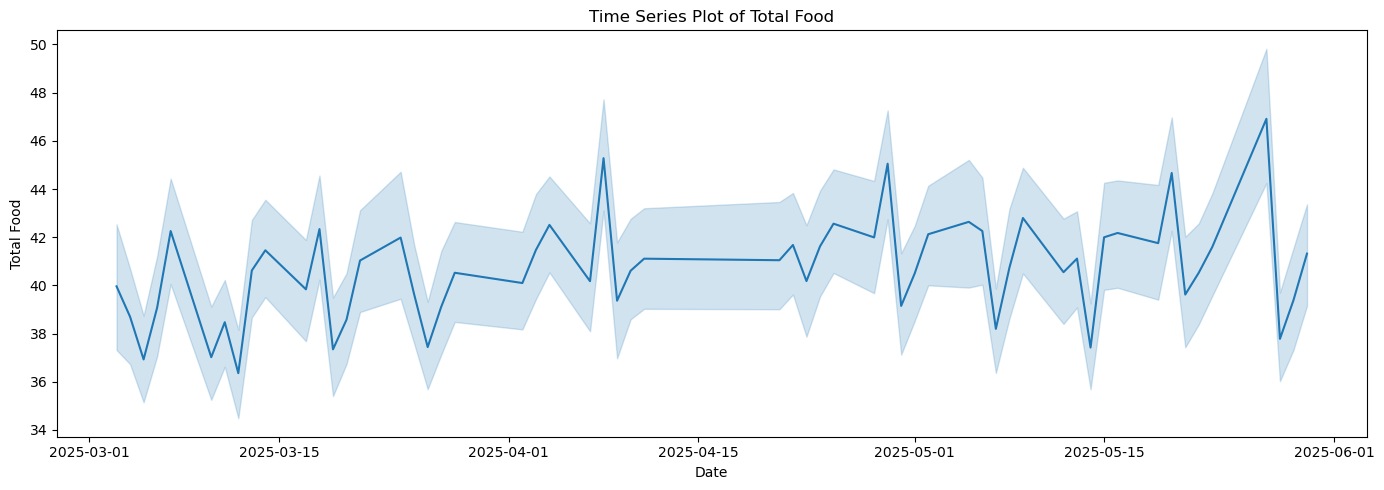

In [41]:
# Plot full time series for a numeric column
plt.figure(figsize=(14, 5))
sns.lineplot(data=dfs, x=dfs.index, y='total')
plt.title("Time Series Plot of Total Food")
plt.xlabel("Date")
plt.ylabel("Total Food")
plt.tight_layout()
plt.show()

---
# Food Popularity
---

In [4]:
breakfast_file = "../data/preprocessed-data/breakfast_combined.csv"
lunch_file = "../data/preprocessed-data/lunch_combined.csv"
sales_file = "../data/preprocessed-data/sales.csv"

bf_df, l_df, s_df = prepare_popularity_data(breakfast_file, lunch_file, sales_file)

num_cols = [
    "served_non-reimbursable", "discarded_total", "discarded_cost",
    "subtotal_cost", "left_over_percent_of_offered", "left_over_cost",
    "left_over_total", "production_cost_total"
]

if bf_df is not None:
    bf_df = clean_numeric(bf_df, num_cols)
if l_df is not None:
    l_df = clean_numeric(l_df, num_cols)

food_popularity(bf_df, l_df, s_df)

Top 10 Breakfast Items (by served_total):
                                                  name  served_reimbursable
7                                   Apple Juice (Each)               422347
99                       Orange Tangerine Juice (Each)               227110
83                       Mini Maple Pancakes (Package)               196086
2                                 1% White Milk (Each)               189429
19                                       Bagel (Bagel)                92610
71                        Honey Cheerios Cereal (Each)                71032
57                                 Cream Cheese (Each)                70942
110               Red Delicious Apple (Each - serving)                69694
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...                63964
54                         Cinnamon Chex Cereal (Each)                59553

Top 10 Lunch Items (by served_total):
                                     name  served_reimbursable
169        Fat Free 

In [5]:
net_consumption(bf_df, l_df)

=== NET CONSUMPTION POPULARITY RANKINGS ===

Top 15 Breakfast Items (by Net Consumption):
                                             Item Name  Net Consumption  \
7                                   Apple Juice (Each)        422247.16   
99                       Orange Tangerine Juice (Each)        227001.49   
83                       Mini Maple Pancakes (Package)        195252.97   
2                                 1% White Milk (Each)        188965.25   
19                                       Bagel (Bagel)         91235.15   
57                                 Cream Cheese (Each)         70882.48   
71                        Honey Cheerios Cereal (Each)         70799.31   
110               Red Delicious Apple (Each - serving)         69423.46   
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...         63588.42   
54                         Cinnamon Chex Cereal (Each)         59150.37   
29                        Blueberry Chex Cereal (Each)         50500.01   
64        

In [6]:
leftover_rate(bf_df, l_df)

=== LEFTOVER RATE RANKINGS ===

Top 15 Breakfast Items (Highest Leftover Rate - Most Waste):
                                             Item Name  Leftover Rate (%)  \
62                      Fat Free Chocolate Milk (Each)              98.83   
37   Cereal, Cinnamon Toasters, Malt-O-Meal, IW (Su...              60.26   
64                          Fat Free White Milk (Each)              53.49   
43            Cherry Flavored Dried Cranberries (Each)              53.12   
63        Fat Free Unflavored Shelf-Stable Milk (Each)              52.70   
80   Milk, Lactose Free,  Fat Free, Shelf-Stable (E...              51.28   
96            Orange Flavored Dried Cranberries (Each)              50.00   
132   Watermelon Flavored Dried Cranberries (2 Eaches)              48.05   
17                        Assorted Cereal (Cereal Cup)              47.13   
101             Patty, Chicken, Breaded, WG (2 strips)              46.88   
66                       Frozen, Blueberries (1/2 cup)      

---
# Time Series Analysis


---
# Optimization
---

In [3]:
# Define file paths
breakfast_file = '../data/preprocessed-data/breakfast_combined.csv'
lunch_file = '../data/preprocessed-data/lunch_combined.csv'
student_counts_file = '../data/preprocessed-data/2022-2025 Fairfax County School Student Count.csv'

# Prepare all data needed for the optimization models
opt_data = prepare_optimization_data(breakfast_file, lunch_file, student_counts_file)

--- Preparing Optimization Data ---
Data preparation complete.


In [4]:
if opt_data:
    # Set up parameters
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]

    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Run the optimization and generate the item breakdown
    results_df = run_meal_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    generate_item_breakdown(results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization.csv')


--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261136.18

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 290 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $657.94 (Budget: $732340.84)

  annandale high:
    Breakfast: 2396 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6617 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.09 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1029 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2219 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1333.23 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 181 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 871 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $430.65 (Budget: $732340.84)

  baileys lower e

In [5]:
if opt_data and opt_data['all_school_lists']:
    run_size_based_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'],
        opt_data['demand'], {s: (139144760 / len(opt_data['schools'])) for s in opt_data['schools']}, 
        36362814, [0.50, 1.00], opt_data['all_school_lists']
    )

--- Starting Size-Based Optimization ---
Categorized 190 schools based on your lists.
Production bounds have been set based on custom school sizes.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $266084.80

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 273 units (Demand: 322, Prod. Bounds: 273-370)
    Lunch: 1243 units (Demand: 1463, Prod. Bounds: 1243-1682)
    School Total Cost: $620.68 (Budget: $732340.84)

  annandale high:
    Breakfast: 2582 units (Demand: 2662, Prod. Bounds: 2582-2742)
    Lunch: 7132 units (Demand: 7353, Prod. Bounds: 7132-7573)
    School Total Cost: $3983.55 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1029 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2219 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1333.23 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 171 units (Demand: 202, Prod

In [6]:
if opt_data:
    monthly_results_df, monthly_school_budgets, monthly_meal_costs = run_proportional_monthly_optimization(opt_data)


Proportional Budget Monthly Optimization (LP)

--- Allocating Budget Based on Student Population ---
Total budget of $139,144,760.00 allocated proportionally.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $4932572.29

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 5478 units (Demand: 6445, Prod. Bounds: 5478-7089)
    Lunch: 24876 units (Demand: 29267, Prod. Bounds: 24876-32193)
    School Total Cost: $12427.67 (Budget: $350842.99)

  annandale high:
    Breakfast: 45262 units (Demand: 53250, Prod. Bounds: 45262-58574)
    Lunch: 124997 units (Demand: 147056, Prod. Bounds: 124997-161761)
    School Total Cost: $69820.52 (Budget: $1584712.58)

  annandale terrace elementary:
    Breakfast: 19454 units (Demand: 22888, Prod. Bounds: 19454-25176)
    Lunch: 41917 units (Demand: 49314, Prod. Bounds: 41917-54245)
    School Total Cost: $25191.53 (Budget: $689847.72)

  armstrong elementar

In [8]:
# Runs the daily Integer Linear Programming (ILP) model
if opt_data:
    # Set up the same daily parameters as the first model
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]
    
    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Call the ILP function with all the required arguments
    ilp_results_df = run_meal_optimization_ilp(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    
    # Generate a separate breakdown file for the ILP results
    generate_item_breakdown(ilp_results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization_ilp.csv')


--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261225.87

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 291 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $658.36 (Budget: $732340.84)

  annandale high:
    Breakfast: 2397 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6618 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.91 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1030 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2220 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1334.06 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 182 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 872 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $431.47 (Budget: $732340.84)

  baileys

In [9]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Calculate the actual cost from 2025 data
    actual_cost_2025 = calculate_actual_annual_cost(opt_data)
    
    # Run the analysis, passing in the actual cost to calculate savings
    analysis_table = analyze_annual_budget(
        monthly_results_df,
        monthly_school_budgets,
        monthly_meal_costs,
        actual_annual_cost=actual_cost_2025
    )
    if analysis_table is not None:
        display(analysis_table)


--- Calculating Baseline (Actual) Annual Food Cost ---
Actual cost for the data period (1 month): $4,893,684.23
Estimated Actual Annual Food Cost: $48,936,842.30

ANALYSIS: Remaining Annual Budget for Non-Food Expenses

--- Overall Financial Summary (Annual) ---
Total Allocated Annual Budget: $139,144,760.00
Grand Total Annual Food Expenses: $40,299,933.41
Grand Total Remaining for Other Expenses: $98,844,826.59

-- Savings Analysis ---
Baseline Actual Annual Food Cost: $48,936,842.30
Optimized Annual Food Cost: $40,299,933.41
Total Annual Savings: $8,636,908.89 (17.65%)

--- Detailed Breakdown by School (Annual) ---


,school,proportional_annual_budget,annual_food_cost,remaining_annual_balance
0,aldrin elementary,"$350,842.99","$124,276.70","$226,566.29"
1,annandale high,"$1,584,712.58","$698,205.17","$886,507.41"
2,annandale terrace elementary,"$689,847.72","$251,915.31","$437,932.41"
3,armstrong elementary,"$299,185.13","$81,377.00","$217,808.13"
4,baileys lower elementary,"$757,648.66","$339,884.89","$417,763.77"
...,...,...,...,...
185,wolftrap elementary,"$354,609.71","$94,034.90","$260,574.81"
186,woodburn elementary,"$520,345.35","$190,236.25","$330,109.11"
187,woodlawn elementary,"$456,849.23","$147,946.36","$308,902.87"
188,woodley hills elementary,"$486,444.88","$166,416.40","$320,028.48"


In [10]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Get the newly prepared data
    savings_df = prepare_savings_analysis_df(
        opt_data,
        monthly_results_df,
        monthly_meal_costs
    )

    if savings_df is not None:
        # --- Interactive Savings Analysis Bubble Chart ---
        fig = px.scatter(
            savings_df,
            x='actual_annual_cost',
            y='optimized_annual_cost',
            size='savings_magnitude',
            color='outcome',

            color_discrete_map={
                'Savings': 'green',
                'Loss': 'red'
            },
            hover_name='school',
            hover_data={
                'size_category': True,
                'savings': ':.2s',
                'savings_magnitude': False
            },
            title='Savings Analysis: Actual vs. Optimized Cost',
            labels={
                'actual_annual_cost': 'Actual Annual Food Cost',
                'optimized_annual_cost': 'Optimized Annual Food Cost',
                'outcome': 'Outcome',
                'savings_magnitude': 'Impact ($)'
            }
        )

        # Add the 45-degree "no savings" reference line
        max_val = max(savings_df['actual_annual_cost'].max(), savings_df['optimized_annual_cost'].max()) * 1.05
        fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val, line=dict(color='Gray', width=2, dash='dash'))
        
        fig.update_layout(legend=dict(font=dict(size=14)))

        fig.show()


--- Calculating Baseline (Actual) Annual Food Cost ---
Actual cost for the data period (1 month): $4,893,684.23
Estimated Actual Annual Food Cost: $48,936,842.30


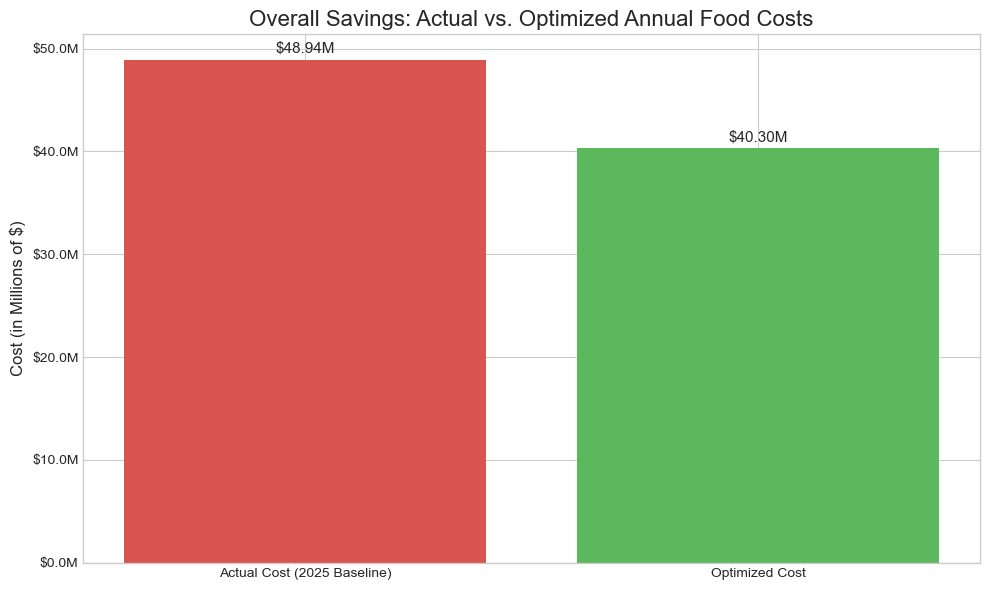


--- Final Savings Summary ---
Total Annual Savings: $8,636,908.89 (17.65%)


In [16]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    
    # Get the actual annual cost from 2025 data
    actual_annual_cost = calculate_actual_annual_cost(opt_data)
    
    # --- 2. Calculate the Total Optimized Cost ---
    # This logic is from your analyze_annual_budget function
    meal_cost_map = {'Breakfast': monthly_meal_costs[0], 'Lunch': monthly_meal_costs[1]}
    
    # We create a temporary copy to avoid a SettingWithCopyWarning
    results_copy = monthly_results_df.copy()
    results_copy['monthly_food_cost'] = results_copy.apply(
        lambda row: row['optimal_quantity'] * meal_cost_map[row['meal_type']], axis=1
    )
    optimized_monthly_cost = results_copy['monthly_food_cost'].sum()
    optimized_annual_cost = optimized_monthly_cost * 10
    
    # --- 3. Create the Bar Chart ---
    labels = ['Actual Cost (2025 Baseline)', 'Optimized Cost']
    values = [actual_annual_cost, optimized_annual_cost]
    colors = ['#d9534f', '#5cb85c'] # Red for actual, green for optimized
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.bar(labels, values, color=colors)
    
    # Add labels and title
    ax.set_title('Overall Savings: Actual vs. Optimized Annual Food Costs', fontsize=16)
    ax.set_ylabel('Cost (in Millions of $)', fontsize=12)
    
    # Format the y-axis to show currency in millions
    ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    
    # Add data labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'${height/1e6:.2f}M',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # --- 4. Print a final summary ---
    savings = actual_annual_cost - optimized_annual_cost
    savings_percent = (savings / actual_annual_cost) * 100
    print("\n--- Final Savings Summary ---")
    print(f"Total Annual Savings: ${savings:,.2f} ({savings_percent:.2f}%)")


ANALYSIS: Savings by School Size Category
Successfully aggregated savings by school size.


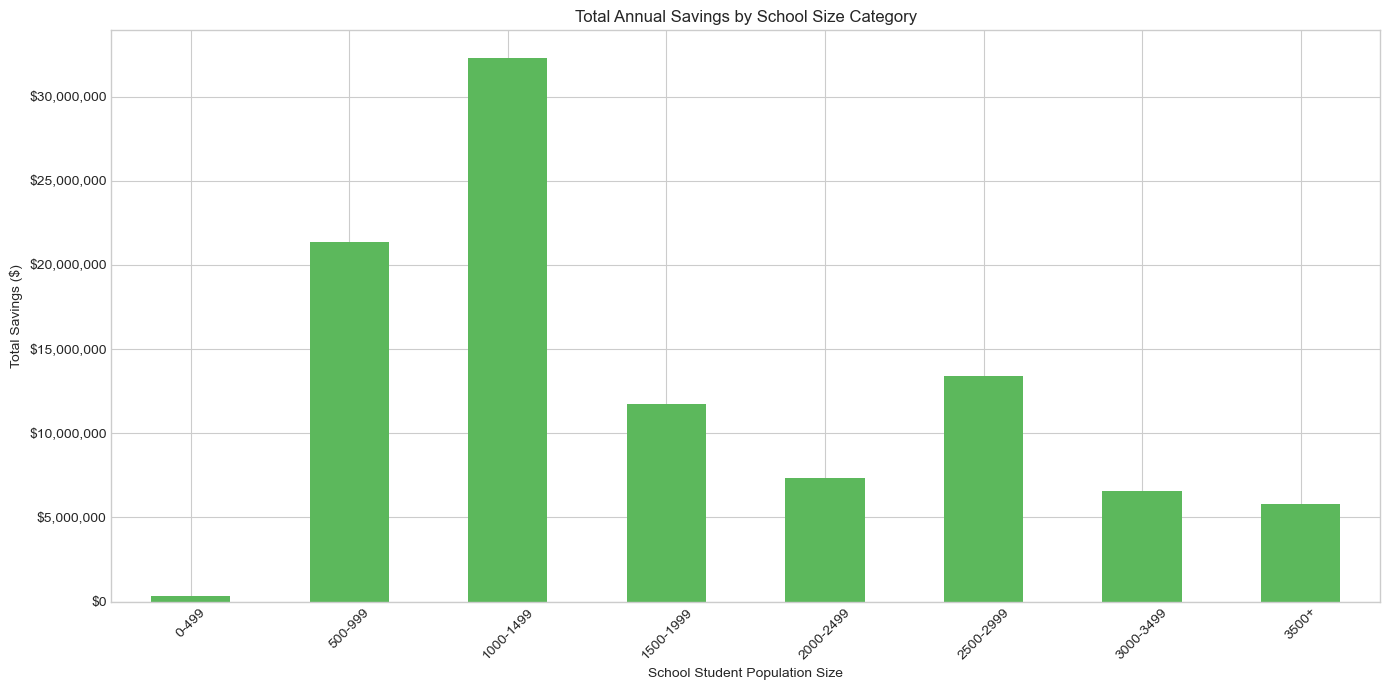

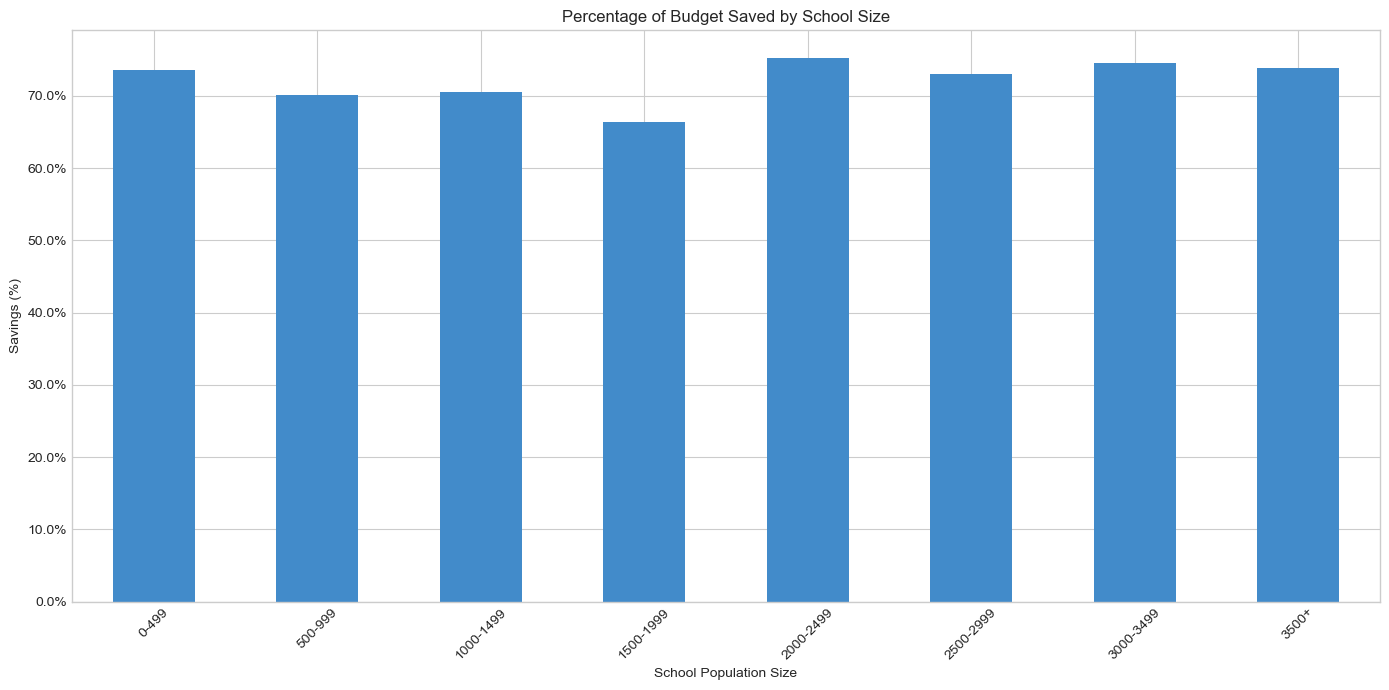

In [18]:
if 'monthly_results_df' in locals() and monthly_results_df is not None:
    # Call the function to get the aggregated data by size
    savings_by_size_df = analyze_savings_by_school_size(
        monthly_results_df,
        monthly_school_budgets,
        monthly_meal_costs,
        opt_data['df_sizes']
    )

    if savings_by_size_df is not None:
        range_map = {
            'xxs': '0-499',
            'xs': '500-999',
            's': '1000-1499',
            'm': '1500-1999',
            'l': '2000-2499',
            'xl': '2500-2999',
            'xxl': '3000-3499',
            'xxxl': '3500+'
        }
        savings_by_size_df['count_range'] = savings_by_size_df['size_category'].map(range_map)
        # Sort by size category for a logical order in the plot
        size_order = ['xxs', 'xs', 's', 'm', 'l', 'xl', 'xxl', 'xxxl']
        savings_by_size_df['size_category'] = pd.Categorical(savings_by_size_df['size_category'], categories=size_order, ordered=True)
        savings_by_size_df = savings_by_size_df.sort_values('size_category')
        
        # --- Total Savings in Dollars ---
        plt.style.use('seaborn-v0_8-whitegrid')
        ax1 = savings_by_size_df.plot(
            x='count_range',
            y='total_savings',
            kind='bar',
            figsize=(14, 7),
            title='Total Annual Savings by School Size Category',
            rot=45,
            legend=False,
            color='#5cb85c'
        )
        ax1.set_xlabel("School Student Population Size")
        ax1.set_ylabel("Total Savings ($)")
        ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # --- Percentage of Budget Saved ---
        ax2 = savings_by_size_df.plot(
            x='count_range',
            y='percent_savings',
            kind='bar',
            figsize=(14, 7),
            title='Percentage of Budget Saved by School Size',
            rot=45,
            legend=False,
            color='#428bca'
        )
        ax2.set_xlabel("School Population Size")
        ax2.set_ylabel("Savings (%)")
        ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))
        plt.tight_layout()
        plt.show()